<a href="https://colab.research.google.com/github/sitahlango-maker/Financial_Inclusion/blob/main/cleanfinancialinclusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Installing Basic Liberaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imports the pandas library for data handling and analysis.
import pandas as pd

In [7]:
# Loads the Kenya survey data file from the public GitHub repository.
df_ken = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Kenya.csv')

# Loads the Tanzania survey data file from the public GitHub repository.
df_tza = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Tanzania.csv')

# Loads the Uganda survey data file from the public GitHub repository.
df_uga = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Uganda.csv')

In [8]:
# Prints the number of rows and columns for each country’s survey file to confirm successful loading.
print("Kenya shape:", df_ken.shape)
print("Tanzania shape:", df_tza.shape)
print("Uganda shape:", df_uga.shape)

# Shows the first 15 column names of the Kenya file to check the structure.
print("\nKenya columns:", df_ken.columns.tolist()[:15], "...")

Kenya shape: (1000, 183)
Tanzania shape: (1000, 183)
Uganda shape: (1000, 183)

Kenya columns: ['year', 'economy', 'economycode', 'regionwb', 'pop_adult', 'wpid_random', 'wgt', 'female', 'age', 'educ', 'inc_q', 'emp_in', 'urbanicity', 'account_fin', 'account_mob'] ...


**Cleaning** **initial** **Findex** **Dataset**

In [9]:
# Defines a function to clean one Findex survey file.
def clean_findex(df, country_code, country_name):

    # Creates a copy of the input DataFrame to avoid changing the original.
    df = df.copy()

    # Adds the full country name as a new column.
    df['country'] = country_name

    # Adds the three-letter country code as a new column.
    df['country_code'] = country_code

    # Checks if the survey weight column exists and converts it to numeric values.
    if 'wgt' in df.columns:
        df['wgt'] = pd.to_numeric(df['wgt'], errors='coerce')

    # Defines the main outcome columns that measure mobile money and digital use.
    target_cols = ['account_mob', 'dig_account', 'anydigpayment']

    # Loops through each outcome column and converts it to numeric values.
    for col in target_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Lists the most important columns to keep in the cleaned file.
    keep = ['country', 'country_code', 'wgt', 'female', 'age', 'educ', 'inc_q',
            'urbanicity', 'account_mob', 'dig_account', 'anydigpayment', 'internet_use']

    # Removes any listed columns that do not exist in the DataFrame.
    keep = [c for c in keep if c in df.columns]

    # Keeps only the selected columns and discards the rest.
    df = df[keep]

    # Returns the cleaned DataFrame.
    return df

# Loads the Kenya survey file directly from the public GitHub repository.
df_ken = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Kenya.csv')

# Loads the Tanzania survey file directly from the public GitHub repository.
df_tza = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Tanzania.csv')

# Loads the Uganda survey file directly from the public GitHub repository.
df_uga = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Findex_Microdata_2025_Uganda.csv')

# Cleans the Kenya data using the function defined earlier.
df_ken_clean = clean_findex(df_ken, 'KEN', 'Kenya')

# Cleans the Tanzania data using the function defined earlier.
df_tza_clean = clean_findex(df_tza, 'TZA', 'Tanzania')

# Cleans the Uganda data using the function defined earlier.
df_uga_clean = clean_findex(df_uga, 'UGA', 'Uganda')

# Combines the three cleaned files into one table (df_micro).
df_micro = pd.concat([df_ken_clean, df_tza_clean, df_uga_clean], ignore_index=True)

# Prints a confirmation message with the shape of the combined table.
print("df_micro defined. Shape:", df_micro.shape)

df_micro defined. Shape: (3000, 12)


In [10]:
# Cleans Kenya survey data using the cleaning function.
df_ken_clean = clean_findex(df_ken, 'KEN', 'Kenya')

# Cleans Tanzania survey data using the cleaning function.
df_tza_clean = clean_findex(df_tza, 'TZA', 'Tanzania')

# Cleans Uganda survey data using the cleaning function.
df_uga_clean = clean_findex(df_uga, 'UGA', 'Uganda')

# Combines three cleaned files into one single table.
df_micro = pd.concat([df_ken_clean, df_tza_clean, df_uga_clean], ignore_index=True)

# Prints total rows and columns of combined table.
print("Combined microdata shape:", df_micro.shape)

# Shows how many rows belong to each country.
print(df_micro['country'].value_counts())

# Prints percentage of missing values in each column (top 12).
print("\nMissing values (%):\n", df_micro.isna().mean().sort_values(ascending=False).head(12))

Combined microdata shape: (3000, 12)
country
Kenya       1000
Tanzania    1000
Uganda      1000
Name: count, dtype: int64

Missing values (%):
 educ             0.001
country          0.000
wgt              0.000
country_code     0.000
female           0.000
age              0.000
inc_q            0.000
urbanicity       0.000
account_mob      0.000
dig_account      0.000
anydigpayment    0.000
internet_use     0.000
dtype: float64


**Loading the country level dataset**

In [11]:
# Loads prevalence index file .
df_preval = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/refs/heads/main/Colab%20Notebooks/FinancialInclution/Mobile%20Money%20Prevalent%20Index-2020-23-Public(MMPI%202020-23).csv')

# Keeps only needed columns and removes rows without valid code.
df_preval = df_preval[['Country', 'ISO3', 'Mobile Money Prevalence (2023)']].dropna(subset=['ISO3'])

# Changes column names to be short and clear.
df_preval.columns = ['country_name', 'country_code', 'mmpi_2023']

# Keeps only Kenya, Tanzania, and Uganda rows.
df_preval = df_preval[df_preval['country_code'].isin(['KEN', 'TZA', 'UGA'])]

In [12]:
# Loads regulatory index file
df_reg = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/Mobile_Money_Regulatory_Index_Database_2025_v2(Data).csv')

# Keeps only rows from year 2025 (latest data).
df_reg = df_reg[df_reg['Year'] == 2025]

# Keeps only selected columns that are most relevant.
df_reg = df_reg[['Country', 'Index', 'Consumer Protection', 'KYC Proportionality',
                 'Entry-level transaction limits', 'Maximum transaction limits', 'Agent Eligibility']]

# Changes column names to be short and clear.
df_reg.columns = ['country_name', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
                  'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']

# Adds short country code using country name.
df_reg['country_code'] = df_reg['country_name'].map({'Kenya': 'KEN', 'Tanzania': 'TZA', 'Uganda': 'UGA'})

# Keeps only Kenya, Tanzania, and Uganda rows.
df_reg = df_reg[df_reg['country_code'].isin(['KEN', 'TZA', 'UGA'])]

In [13]:
# Loads deployment tracker file
df_deploy = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/refs/heads/main/Colab%20Notebooks/FinancialInclution/Mobile%20Money%20Deployment.csv')

# Keeps only rows for Kenya, Tanzania, and Uganda.
df_deploy = df_deploy[df_deploy['Country ISO Code'].isin(['KEN', 'TZA', 'UGA'])]

# Counts number of mobile money providers per country.
df_providers = df_deploy.groupby('Country ISO Code').size().reset_index(name='num_providers')

# Changes country code column name to match others.
df_providers = df_providers.rename(columns={'Country ISO Code': 'country_code'})

# Changes launch year to numbers (ignores errors).
df_deploy['launch_year'] = pd.to_numeric(df_deploy['Launch Year'], errors='coerce')

# Finds earliest launch year per country.
df_oldest = df_deploy.groupby('Country ISO Code')['launch_year'].min().reset_index(name='earliest_launch_year')

# Changes country code column name to match others.
df_oldest = df_oldest.rename(columns={'Country ISO Code': 'country_code'})

**Building Country Facts Table**

In [14]:
# Starts country facts table with prevalence category.
df_country_facts = df_preval[['country_code', 'mmpi_2023']].copy()

# Adds regulatory scores using left join.
df_country_facts = df_country_facts.merge(
    df_reg[['country_code', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
            'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']],
    on='country_code',
    how='left'
)

# Combines provider count and earliest launch year.
df_deploy_info = df_providers.merge(df_oldest, on='country_code', how='left')

# Adds provider information to country facts table.
df_country_facts = df_country_facts.merge(df_deploy_info, on='country_code', how='left')

# Prints the final country facts table.
print(df_country_facts)

  country_code  mmpi_2023  reg_index  reg_cons_prot  reg_kyc_prop  \
0          KEN  Very high      88.00         100.00             0   
1          TZA  Very high      87.16          83.33           100   
2          UGA  Very high      88.33         100.00           100   

   reg_entry_lim  reg_max_lim  reg_agent_el  num_providers  \
0            100          100           100              4   
1            100          100           100              6   
2            100          100           100              7   

   earliest_launch_year  
0                  2007  
1                  2008  
2                  2009  


**Selecting Survey Columns and Final Combination**

In [15]:
# Lists most useful columns from survey data.
keep_survey = [
    'country_code', 'female', 'age', 'educ', 'inc_q', 'urbanicity',
    'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt'
]

# Keeps only selected columns from combined survey data.
df_survey_clean = df_micro[keep_survey].copy()

# Joins survey data with country facts using country code.
df_final = df_survey_clean.merge(df_country_facts, on='country_code', how='left')

# Prints final table size to confirm.
print("Final combined dataset shape:", df_final.shape)

# Prints first few rows of final table.
print("First few rows:\n", df_final.head())

# Prints percentage of missing values in each column.
print("\nMissing values (%):\n", df_final.isna().mean().sort_values(ascending=False).head(10))

Final combined dataset shape: (3000, 20)
First few rows:
   country_code  female  age  educ  inc_q  urbanicity  account_mob  \
0          KEN       1   25   2.0      1           1            1   
1          KEN       1   26   2.0      4           1            1   
2          KEN       1   21   2.0      3           1            1   
3          KEN       1   25   2.0      5           1            1   
4          KEN       2   31   3.0      5           2            1   

   dig_account  anydigpayment  internet_use       wgt  mmpi_2023  reg_index  \
0            1              1             1  0.723252  Very high       88.0   
1            1              1             1  0.331405  Very high       88.0   
2            1              1             1  1.071302  Very high       88.0   
3            1              1             1  0.677005  Very high       88.0   
4            1              1             1  0.457662  Very high       88.0   

   reg_cons_prot  reg_kyc_prop  reg_entry_lim  reg_m

**Saving the Final Dataset as CSV**

In [16]:
# Save the dataset as CSV in Colab's temporary storage
df_final.to_csv('FinalCombine.csv', index=False)

# Install git if not already available (usually pre-installed in Colab)
!apt-get update -qq && apt-get install -y git

# Configure git with your details (replace with your own email and username)
!git config --global user.email "your-email@example.com"
!git config --global user.name "Your GitHub Username"

# Clone your repository (replace with your actual repo URL)
!git clone https://github.com/sitahlango-maker/Financial_Inclusion.git
%cd Financial_Inclusion

# Move the CSV file to the desired folder inside the repo
!mkdir -p "Colab Notebooks/FinancialInclution"
!mv ../FinalCombine.csv "Colab Notebooks/FinancialInclution/FinalCombine.csv"

# Add, commit, and push the file to GitHub
!git add "Colab Notebooks/FinancialInclution/FinalCombine.csv"
!git commit -m "Add FinalCombine.csv - combined Findex and country-level dataset"
!git push origin main

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.
Cloning into 'Financial_Inclusion'...
remote: Enumerating objects: 759, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (197/197), done.
remote: Total 759 (delta 157), reused 34 (delta 34), pack-reused 528 (from 2)
Receiving objects: 100% (759/759), 17.69 MiB | 15.48 MiB/s, done.
Resolving deltas: 100% (370/370), done.
/content/Financial_Inclusion
[main 376daf5] Add FinalCombine.csv - combined Findex and country-level dataset
 1 file changed, 0 insertions(+), 0 deletions(-)
 rewrite Colab Notebooks/FinancialInclution/FinalCombine.csv (97%)
fatal:

In [17]:
# Load the Mobile Money Deployment Tracker
df_preval = pd.read_csv('https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/refs/heads/main/Colab%20Notebooks/FinancialInclution/Mobile%20Money%20Prevalent%20Index-2020-23-Public(MMPI%202020-23).csv',
 )

# Rename column for merging
df_preval = df_preval[['Country', 'ISO3', 'Mobile Money Prevalence (2023)']]

#--Remove rows without valid country code
df_preval = df_preval.dropna(subset=['ISO3'])

#Select the columns to be used:
df_preval = df_preval[['Country', 'ISO3', 'Mobile Money Prevalence (2023)']]

#Make the column names short and clear
df_preval.columns = ['country_name', 'country_code', 'mmpi_2023']


#Keep only three countries (Kenya, Uganda and Tanzania)
df_preval = df_preval[df_preval['country_code'].isin(['KEN', 'TZA', 'UGA'])]

df_preval.columns.tolist()

['country_name', 'country_code', 'mmpi_2023']

**Combining the four latter GSMA datasets With the Original Findex Dataset**

In [18]:
df_country_facts = df_preval[['country_code', 'mmpi_2023']].copy()
df_country_facts = df_country_facts.merge(df_reg[['country_code', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
                                                  'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']],
                                          on='country_code', how='left')
df_deploy_info = df_providers.merge(df_oldest, on='country_code', how='left')
df_country_facts = df_country_facts.merge(df_deploy_info, on='country_code', how='left')

In [19]:
# Preparing microdata (the three Findex survey files already combined in df_micro)
# Adding country_code (just in case it's not updated properly)
df_micro['country_code'] = df_micro['country'].map({
    'Kenya': 'KEN',
    'Tanzania': 'TZA',
    'Uganda': 'UGA'
})

In [20]:
# Keep only the most useful survey columns
keep_survey = [
    'country_code', 'female', 'age', 'educ', 'inc_q', 'urbanicity',
    'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt'
]
df_survey_clean = df_micro[keep_survey].copy()

In [21]:
# Building one small country facts table from the other five sources
# Starting with prevalence dataset as base
df_country_facts = df_preval[['country_code', 'mmpi_2023']].copy()

In [22]:
# Adding regulatory scores
df_country_facts = df_country_facts.merge(
    df_reg[['country_code', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop',
            'reg_entry_lim', 'reg_max_lim', 'reg_agent_el']],
    on='country_code',
    how='left'
)

In [23]:
# Adding the number of providers and earliest launch year
df_providers = df_deploy.groupby('Country ISO Code').size().reset_index(name='num_providers')
df_earliest = df_deploy.groupby('Country ISO Code')['launch_year'].min().reset_index(name='earliest_launch')
df_providers = df_providers.rename(columns={'Country ISO Code': 'country_code'})
df_earliest  = df_earliest.rename(columns={'Country ISO Code': 'country_code'})

df_deploy_info = df_providers.merge(df_earliest, on='country_code', how='left')
df_country_facts = df_country_facts.merge(df_deploy_info, on='country_code', how='left')

In [24]:
# Joining the country facts to every row of the survey data
df_final = df_survey_clean.merge(
    df_country_facts,
    on='country_code',
    how='left'
)

In [25]:
# Checking the result
print("Final combined dataset shape:", df_final.shape)
print("First few rows:\n", df_final.head())
print("\nMissing values (%):\n", df_final.isna().mean().sort_values(ascending=False).head(10))

Final combined dataset shape: (3000, 20)
First few rows:
   country_code  female  age  educ  inc_q  urbanicity  account_mob  \
0          KEN       1   25   2.0      1           1            1   
1          KEN       1   26   2.0      4           1            1   
2          KEN       1   21   2.0      3           1            1   
3          KEN       1   25   2.0      5           1            1   
4          KEN       2   31   3.0      5           2            1   

   dig_account  anydigpayment  internet_use       wgt  mmpi_2023  reg_index  \
0            1              1             1  0.723252  Very high       88.0   
1            1              1             1  0.331405  Very high       88.0   
2            1              1             1  1.071302  Very high       88.0   
3            1              1             1  0.677005  Very high       88.0   
4            1              1             1  0.457662  Very high       88.0   

   reg_cons_prot  reg_kyc_prop  reg_entry_lim  reg_m

In [26]:
# Saving the final file
df_final.to_csv(
    'https://github.com/sitahlango-maker/Financial_Inclusion/tree/main/Colab%20Notebooks/FinancialInclution',
    index=False
)

In [27]:
# Import libraries needed for data preparation and modelling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [28]:
# Set display options for better readability
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

**Saving the Cleaned Raw Dataset**

In [29]:
df_final.to_csv('cleaned_multiple_country_dataset.csv',index=False)

In [30]:
# Display basic information about the loaded data
print("Dataset shape:", df_final.shape)
print("\nFirst few rows:")
print(df_final.head())
print("\nColumn names:")
print(df_final.columns.tolist())
print("\nMissing values (%):")
print(df_final.isna().mean().sort_values(ascending=False).head(10))


Dataset shape: (3000, 20)

First few rows:
  country_code  female  age   educ  inc_q  urbanicity  account_mob  \
0          KEN       1   25 2.0000      1           1            1   
1          KEN       1   26 2.0000      4           1            1   
2          KEN       1   21 2.0000      3           1            1   
3          KEN       1   25 2.0000      5           1            1   
4          KEN       2   31 3.0000      5           2            1   

   dig_account  anydigpayment  internet_use    wgt  mmpi_2023  reg_index  \
0            1              1             1 0.7233  Very high    88.0000   
1            1              1             1 0.3314  Very high    88.0000   
2            1              1             1 1.0713  Very high    88.0000   
3            1              1             1 0.6770  Very high    88.0000   
4            1              1             1 0.4577  Very high    88.0000   

   reg_cons_prot  reg_kyc_prop  reg_entry_lim  reg_max_lim  reg_agent_el  \
0  

In [31]:
# Imports pandas for loading and managing data tables.
import pandas as pd

# Imports numpy for numerical calculations and array handling.
import numpy as np

# Imports matplotlib and seaborn for creating plots and visual checks.
import matplotlib.pyplot as plt
import seaborn as sns

# Imports tools from scikit-learn for splitting data and building models.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [32]:

# Prints the shape (rows and columns) of the loaded data to confirm it is correct.
print("Dataset shape:", df_final.shape)


Dataset shape: (3000, 20)


In [33]:

# Prints all column names to see what features are available.
print("\nColumn names:")
print(df_final.columns.tolist())


Column names:
['country_code', 'female', 'age', 'educ', 'inc_q', 'urbanicity', 'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt', 'mmpi_2023', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el', 'num_providers', 'earliest_launch']


In [34]:
# Prints the percentage of missing values in each column (sorted highest to lowest).
print("\nMissing values (%):")
print(df_final.isna().mean().sort_values(ascending=False).head(15))


Missing values (%):
educ            0.0010
country_code    0.0000
female          0.0000
age             0.0000
inc_q           0.0000
urbanicity      0.0000
account_mob     0.0000
dig_account     0.0000
anydigpayment   0.0000
internet_use    0.0000
wgt             0.0000
mmpi_2023       0.0000
reg_index       0.0000
reg_cons_prot   0.0000
reg_kyc_prop    0.0000
dtype: float64


In [35]:
# Prints the data types of each column to check they are correct.
print("\nData types:")
print(df_final.dtypes)


Data types:
country_code        object
female               int64
age                  int64
educ               float64
inc_q                int64
urbanicity           int64
account_mob          int64
dig_account          int64
anydigpayment        int64
internet_use         int64
wgt                float64
mmpi_2023           object
reg_index          float64
reg_cons_prot      float64
reg_kyc_prop         int64
reg_entry_lim        int64
reg_max_lim          int64
reg_agent_el         int64
num_providers        int64
earliest_launch      int64
dtype: object


In [36]:
country_series = df_final['country_code'].copy()

In [37]:
#IMPORT LIBRARIES
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [38]:
# LOAD DATASET

url = "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv"

df = pd.read_csv(url)

# Rename female -> gender
df = df.rename(
    columns={
        "female": "gender"
    }
)

print(df.shape)

print(df.columns.tolist())

df.head()

(3000, 20)
['country_code', 'gender', 'age', 'educ', 'inc_q', 'urbanicity', 'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt', 'mmpi_2023', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el', 'num_providers', 'earliest_launch']


,country_code,gender,age,educ,inc_q,urbanicity,account_mob,dig_account,anydigpayment,internet_use,wgt,mmpi_2023,reg_index,reg_cons_prot,reg_kyc_prop,reg_entry_lim,reg_max_lim,reg_agent_el,num_providers,earliest_launch
0,KEN,1,25,2.0000,1,1,1,1,1,1,0.7233,Very high,88.0000,100.0000,0,100,100,100,4,2007
1,KEN,1,26,2.0000,4,1,1,1,1,1,0.3314,Very high,88.0000,100.0000,0,100,100,100,4,2007
2,KEN,1,21,2.0000,3,1,1,1,1,1,1.0713,Very high,88.0000,100.0000,0,100,100,100,4,2007
3,KEN,1,25,2.0000,5,1,1,1,1,1,0.6770,Very high,88.0000,100.0000,0,100,100,100,4,2007
4,KEN,2,31,3.0000,5,2,1,1,1,1,0.4577,Very high,88.0000,100.0000,0,100,100,100,4,2007


In [39]:
# DATA AUDIT

print("="*70)
print("DATASET INFORMATION")
print("="*70)

print("\nDataset Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

print("\nCountry Distribution")
print(df["country_code"].value_counts())

print("\nTarget Distribution (dig_account)")
print(df["dig_account"].value_counts())

print("\nData Types")
print(df.dtypes)

DATASET INFORMATION

Dataset Shape
(3000, 20)

Missing Values
country_code       0
gender             0
age                0
educ               3
inc_q              0
urbanicity         0
account_mob        0
dig_account        0
anydigpayment      0
internet_use       0
wgt                0
mmpi_2023          0
reg_index          0
reg_cons_prot      0
reg_kyc_prop       0
reg_entry_lim      0
reg_max_lim        0
reg_agent_el       0
num_providers      0
earliest_launch    0
dtype: int64

Duplicate Records
56

Country Distribution
country_code
KEN    1000
TZA    1000
UGA    1000
Name: count, dtype: int64

Target Distribution (dig_account)
dig_account
1    2282
0     718
Name: count, dtype: int64

Data Types
country_code        object
gender               int64
age                  int64
educ               float64
inc_q                int64
urbanicity           int64
account_mob          int64
dig_account          int64
anydigpayment        int64
internet_use         int64
wgt        

In [40]:
# SINGLE SOURCE OF TRUTH DATASET

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"
os.makedirs(MODEL_PATH, exist_ok=True)

DATA_URL = "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv"

df = pd.read_csv(DATA_URL)

# Standardize gender naming
df = df.rename(columns={"female": "gender"})

print("Dataset shape:", df.shape)
print(df.columns.tolist())

print("\nGender check:")
print("gender" in df.columns)
print("female" in df.columns)
print(df["gender"].value_counts(dropna=False))

Dataset shape: (3000, 20)
['country_code', 'gender', 'age', 'educ', 'inc_q', 'urbanicity', 'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt', 'mmpi_2023', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el', 'num_providers', 'earliest_launch']

Gender check:
True
False
gender
1    1603
2    1397
Name: count, dtype: int64


In [41]:
# PREPROCESSING PIPELINE

TARGET = "dig_account"

LEAKAGE_COLUMNS = [
    "account_mob",
    "anydigpayment"
]

def preprocess_data(df):
    data = df.copy()

    data = data.drop(
        columns=LEAKAGE_COLUMNS,
        errors="ignore"
    )

    y = data[TARGET].astype(int)

    X = data.drop(columns=[TARGET])

    country = X["country_code"].copy()

    X = pd.get_dummies(
        X,
        drop_first=False,
        dtype=np.uint8
    )

    X = X.fillna(0)

    return X, y, country


X, y, country = preprocess_data(df)

feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    os.path.join(MODEL_PATH, "feature_columns.joblib")
)

print("\nFeature check:")
print("gender" in feature_columns)
print("female" in feature_columns)
print(feature_columns)


Feature check:
True
False
['gender', 'age', 'educ', 'inc_q', 'urbanicity', 'internet_use', 'wgt', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el', 'num_providers', 'earliest_launch', 'country_code_KEN', 'country_code_TZA', 'country_code_UGA', 'mmpi_2023_Very high']


In [42]:
# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

country_train = country.loc[X_train.index]
country_test = country.loc[X_test.index]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nX_test gender distribution:")
print(X_test["gender"].value_counts(dropna=False))

print("\nMapped gender:")
print(
    X_test["gender"].map({
        1: "Female",
        2: "Male"
    }).value_counts(dropna=False)
)

X_train shape: (2400, 19)
X_test shape: (600, 19)

X_test gender distribution:
gender
1    325
2    275
Name: count, dtype: int64

Mapped gender:
gender
Female    325
Male      275
Name: count, dtype: int64


In [43]:
# DEVELOPMENT OF THE POOLED XGBOOST MODEL

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Define target variable
TARGET = "dig_account"

y = df_final[TARGET].astype(int)

# Remove target and leakage variables
X = df_final.drop(
    columns=[
        "dig_account",
        "account_mob",
        "anydigpayment"
    ],
    errors="ignore"
)

# One-hot encode categorical columns such as country_code and mmpi_2023
X = pd.get_dummies(
    X,
    drop_first=False,
    dtype=int
)

# Fill remaining missing values
X = X.fillna(0)

# Create training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train pooled model
pooled_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.90,
    colsample_bytree=0.90,
    eval_metric="logloss",
    random_state=42
)

pooled_model.fit(X_train, y_train)

# Generate predictions
pooled_pred = pooled_model.predict(X_test)
pooled_prob = pooled_model.predict_proba(X_test)[:, 1]

print("Pooled model trained successfully.")
print("Feature matrix shape:", X.shape)

Pooled model trained successfully.
Feature matrix shape: (3000, 19)


In [44]:
# EVALUATE POOLED MODEL

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

pred = pooled_model.predict(X_test)

prob = pooled_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,pred))

print("Precision :", precision_score(y_test,pred))

print("Recall :", recall_score(y_test,pred))

print("F1 Score :", f1_score(y_test,pred))

print("ROC AUC :", roc_auc_score(y_test,prob))

Accuracy : 0.76
Precision : 0.8170731707317073
Recall : 0.881578947368421
F1 Score : 0.8481012658227848
ROC AUC : 0.8106115984405456


In [45]:
# FULL RESET TO GENDER DATASET

import os
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"

DATA_URL = "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv"

df = pd.read_csv(DATA_URL)

df = df.rename(columns={"female": "gender"})

print("Data columns:")
print(df.columns.tolist())

TARGET = "dig_account"

LEAKAGE_COLUMNS = [
    "account_mob",
    "anydigpayment"
]

data = df.copy()
data = data.drop(columns=LEAKAGE_COLUMNS, errors="ignore")

y = data[TARGET].astype(int)
X = data.drop(columns=[TARGET])

country = X["country_code"].copy()

X = pd.get_dummies(
    X,
    drop_first=False,
    dtype=np.uint8
)

X = X.fillna(0)

print("\nFeature check before split:")
print("gender" in X.columns)
print("female" in X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

country_train = country.loc[X_train.index]
country_test = country.loc[X_test.index]

print("\nFeature check after split:")
print("gender" in X_train.columns)
print("female" in X_train.columns)

pooled_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.90,
    colsample_bytree=0.90,
    eval_metric="logloss",
    random_state=42
)

pooled_model.fit(X_train, y_train)

joblib.dump(
    pooled_model,
    os.path.join(MODEL_PATH, "pooled_model.joblib")
)

joblib.dump(
    list(X_train.columns),
    os.path.join(MODEL_PATH, "feature_columns.joblib")
)

print("\nModel retrained and saved.")
print("gender" in pooled_model.feature_names_in_)
print("female" in pooled_model.feature_names_in_)

Data columns:
['country_code', 'gender', 'age', 'educ', 'inc_q', 'urbanicity', 'account_mob', 'dig_account', 'anydigpayment', 'internet_use', 'wgt', 'mmpi_2023', 'reg_index', 'reg_cons_prot', 'reg_kyc_prop', 'reg_entry_lim', 'reg_max_lim', 'reg_agent_el', 'num_providers', 'earliest_launch']

Feature check before split:
True
False

Feature check after split:
True
False

Model retrained and saved.
True
False


In [46]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": pooled_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance.head(20))

,Feature,Importance
5,internet_use,0.4547
9,reg_kyc_prop,0.1391
2,educ,0.0635
13,num_providers,0.0578
1,age,0.0489
3,inc_q,0.0465
8,reg_cons_prot,0.0415
6,wgt,0.0404
4,urbanicity,0.0385
7,reg_index,0.0361


,Feature,Importance
5,internet_use,0.4547
9,reg_kyc_prop,0.1391
2,educ,0.0635
13,num_providers,0.0578
1,age,0.0489
3,inc_q,0.0465
8,reg_cons_prot,0.0415
6,wgt,0.0404
4,urbanicity,0.0385
7,reg_index,0.0361


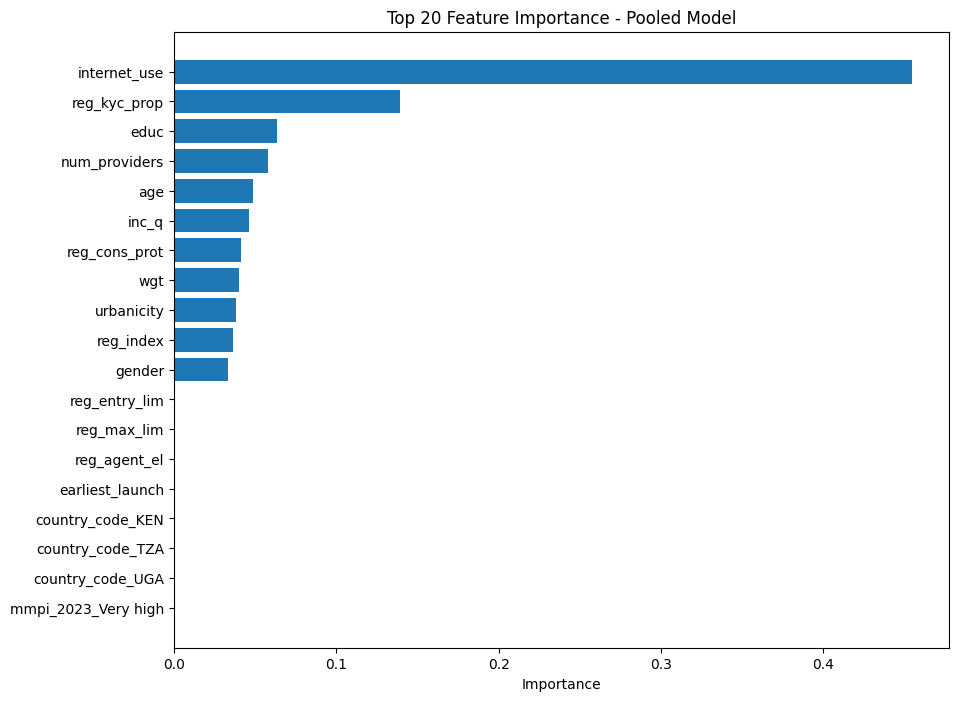

In [47]:
# FEATURE IMPORTANCE

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":pooled_model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

display(importance.head(20))

plt.figure(figsize=(10,8))

plt.barh(

    importance.head(20)["Feature"][::-1],

    importance.head(20)["Importance"][::-1]

)

plt.title("Top 20 Feature Importance - Pooled Model")

plt.xlabel("Importance")

plt.show()

In [48]:
MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"

In [49]:
#  SAVE POOLED MODEL

joblib.dump(

    pooled_model,

    os.path.join(

        MODEL_PATH,

        "pooled_model.joblib"

    )

)

print("Pooled model saved successfully.")

print(os.listdir(MODEL_PATH))

Pooled model saved successfully.
['feature_columns.joblib', 'pooled_model.joblib']


**CREATE HARMONIZED MODEL**

In [50]:
# CREATE HARMONIZED TRAINING DATASET

train_data = X_train.copy()
train_data["target"] = y_train.values
train_data["country"] = country_train.values

min_country_count = train_data["country"].value_counts().min()

harmonized_train = (
    train_data
    .groupby("country", group_keys=False)
    .apply(lambda x: x.sample(min_country_count, random_state=42))
    .reset_index(drop=True)
)

X_train_harmonized = harmonized_train.drop(
    columns=["target", "country"]
)

y_train_harmonized = harmonized_train["target"]

print("Harmonized training dataset created.")
print("Shape:", X_train_harmonized.shape)

print("\nCountry distribution:")
print(harmonized_train["country"].value_counts())

print("\nTarget distribution:")
print(y_train_harmonized.value_counts(normalize=True))

Harmonized training dataset created.
Shape: (2352, 19)

Country distribution:
country
KEN    784
TZA    784
UGA    784
Name: count, dtype: int64

Target distribution:
target
1   0.7623
0   0.2377
Name: proportion, dtype: float64


In [51]:
# CREATE HARMONIZED TRAINING DATA AND TRAIN XGBOOST MODEL

from xgboost import XGBClassifier

# Combine training features, target, and country labels
train_data = X_train.copy()
train_data["target"] = y_train
train_data["country"] = country_train.values

# Find the smallest country sample size
min_country_count = train_data["country"].value_counts().min()

# Sample equal observations from each country
harmonized_train = (
    train_data
    .groupby("country", group_keys=False)
    .apply(lambda x: x.sample(min_country_count, random_state=42))
)

# Separate features and target
X_train_harmonized = harmonized_train.drop(columns=["target", "country"])
y_train_harmonized = harmonized_train["target"]

print("Harmonized training distribution:")
print(harmonized_train["country"].value_counts())

# Train harmonized XGBoost model
harmonized_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.90,
    colsample_bytree=0.90,
    eval_metric="logloss",
    random_state=42
)

harmonized_model.fit(
    X_train_harmonized,
    y_train_harmonized
)

print("Harmonized XGBoost model trained successfully.")

Harmonized training distribution:
country
KEN    784
TZA    784
UGA    784
Name: count, dtype: int64
Harmonized XGBoost model trained successfully.


In [52]:
# EVALUATE AND SAVE HARMONIZED MODEL

harm_pred = harmonized_model.predict(X_test)
harm_prob = harmonized_model.predict_proba(X_test)[:, 1]

print("Harmonized Model Performance")
print("Accuracy :", accuracy_score(y_test, harm_pred))
print("Precision:", precision_score(y_test, harm_pred))
print("Recall   :", recall_score(y_test, harm_pred))
print("F1 Score :", f1_score(y_test, harm_pred))
print("ROC AUC  :", roc_auc_score(y_test, harm_prob))

joblib.dump(
    harmonized_model,
    os.path.join(
        MODEL_PATH,
        "harmonized_model.joblib"
    )
)

print("\nSaved harmonized_model.joblib")

Harmonized Model Performance
Accuracy : 0.7583333333333333
Precision: 0.811623246492986
Recall   : 0.8881578947368421
F1 Score : 0.8481675392670157
ROC AUC  : 0.8132157651072125

Saved harmonized_model.joblib


**Expert Training Function**

In [53]:
# TRAIN COUNTRY EXPERT MODELS

# DEFINE EXPERT TRAINING FUNCTION

def train_country_expert(country_name, X_train, y_train, country_train):

    print(f"\nTraining {country_name} expert...")

    mask = country_train.astype(str).str.upper().values == country_name

    X_country = X_train.loc[mask].copy()
    y_country = y_train.loc[mask].copy()

    print(f"{country_name} samples:", X_country.shape)

    expert_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.90,
        colsample_bytree=0.90,
        eval_metric="logloss",
        random_state=42
    )

    expert_model.fit(X_country, y_country)

    save_path = os.path.join(
        MODEL_PATH,
        f"expert_model_{country_name}.joblib"
    )

    joblib.dump(expert_model, save_path)

    print(f"Saved expert_model_{country_name}.joblib")

    return expert_model


In [54]:
# TRAIN COUNTRY EXPERT MODELS

countries = ["KEN", "TZA", "UGA"]

expert_models = {}

for c in countries:
    expert_models[c] = train_country_expert(
        c,
        X_train,
        y_train,
        country_train
    )

print("\nAll expert models trained and saved.")
print(expert_models.keys())


Training KEN expert...
KEN samples: (801, 19)
Saved expert_model_KEN.joblib

Training TZA expert...
TZA samples: (815, 19)
Saved expert_model_TZA.joblib

Training UGA expert...
UGA samples: (784, 19)
Saved expert_model_UGA.joblib

All expert models trained and saved.
dict_keys(['KEN', 'TZA', 'UGA'])


In [55]:
# EVALUATE COUNTRY EXPERT MODELS

expert_results = []

for_country = country_test.astype(str).str.upper()

for c in countries:

    mask = for_country.values == c

    X_country_test = X_test.loc[mask]
    y_country_test = y_test.loc[mask]

    pred = expert_models[c].predict(X_country_test)
    prob = expert_models[c].predict_proba(X_country_test)[:, 1]

    expert_results.append({
        "Model": f"Expert_{c}",
        "Accuracy": accuracy_score(y_country_test, pred),
        "Precision": precision_score(y_country_test, pred),
        "Recall": recall_score(y_country_test, pred),
        "F1": f1_score(y_country_test, pred),
        "ROC_AUC": roc_auc_score(y_country_test, prob)
    })

expert_results_df = pd.DataFrame(expert_results)

display(expert_results_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Expert_KEN,0.8844,0.9058,0.9719,0.9377,0.7528
1,Expert_TZA,0.6324,0.6750,0.7364,0.7043,0.7207
2,Expert_UGA,0.7269,0.8079,0.8512,0.8290,0.7140


In [56]:
# FULL MODEL COMPARISON TABLE
# Accuracy, F1, ROC-AUC for each model

def evaluate_model(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }


comparison_results = []

# Pooled model
pooled_pred = pooled_model.predict(X_test)
pooled_prob = pooled_model.predict_proba(X_test)[:, 1]

comparison_results.append(
    evaluate_model(
        "Pooled",
        y_test,
        pooled_pred,
        pooled_prob
    )
)

# Harmonized model
harm_pred = harmonized_model.predict(X_test)
harm_prob = harmonized_model.predict_proba(X_test)[:, 1]

comparison_results.append(
    evaluate_model(
        "Harmonized",
        y_test,
        harm_pred,
        harm_prob
    )
)

# Expert models
# Each expert is evaluated only on its own country
country_test_clean = country_test.astype(str).str.upper()

for c in countries:

    mask = country_test_clean.values == c

    X_country_test = X_test.loc[mask]
    y_country_test = y_test.loc[mask]

    expert_pred = expert_models[c].predict(X_country_test)
    expert_prob = expert_models[c].predict_proba(X_country_test)[:, 1]

    comparison_results.append(
        evaluate_model(
            f"Expert_{c}",
            y_country_test,
            expert_pred,
            expert_prob
        )
    )

comparison_df = pd.DataFrame(comparison_results)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

joblib.dump(
    comparison_df,
    os.path.join(MODEL_PATH, "model_comparison_results.joblib")
)

print("Saved model_comparison_results.joblib")

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Expert_KEN,0.8844,0.9058,0.9719,0.9377,0.7528
1,Pooled,0.7600,0.8171,0.8816,0.8481,0.8106
2,Harmonized,0.7583,0.8116,0.8882,0.8482,0.8132
3,Expert_UGA,0.7269,0.8079,0.8512,0.8290,0.7140
4,Expert_TZA,0.6324,0.6750,0.7364,0.7043,0.7207


Saved model_comparison_results.joblib


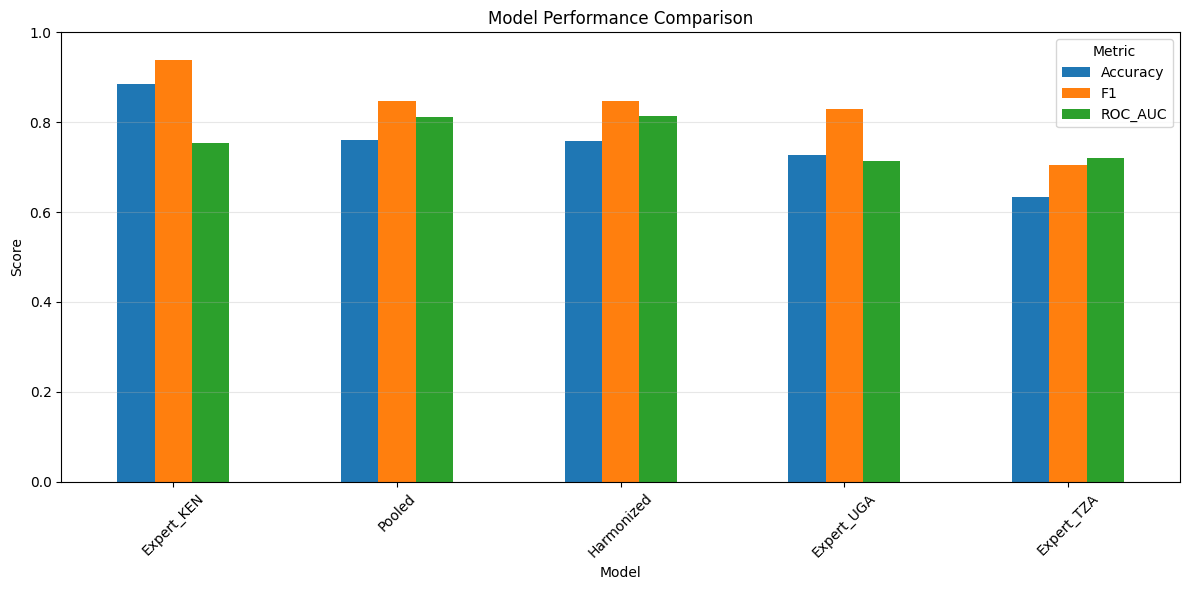

In [57]:
#  PLOT MODEL COMPARISON
# Accuracy, F1, and ROC-AUC

metrics_df = comparison_df[
    ["Model", "Accuracy", "F1", "ROC_AUC"]
].set_index("Model")

ax = metrics_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Feature Comparisson**

,Model,Feature,Importance
0,Pooled,internet_use,0.4547
1,Pooled,reg_kyc_prop,0.1391
2,Pooled,educ,0.0635
3,Pooled,num_providers,0.0578
4,Pooled,age,0.0489
5,Pooled,inc_q,0.0465
6,Pooled,reg_cons_prot,0.0415
7,Pooled,wgt,0.0404
8,Pooled,urbanicity,0.0385
9,Pooled,reg_index,0.0361


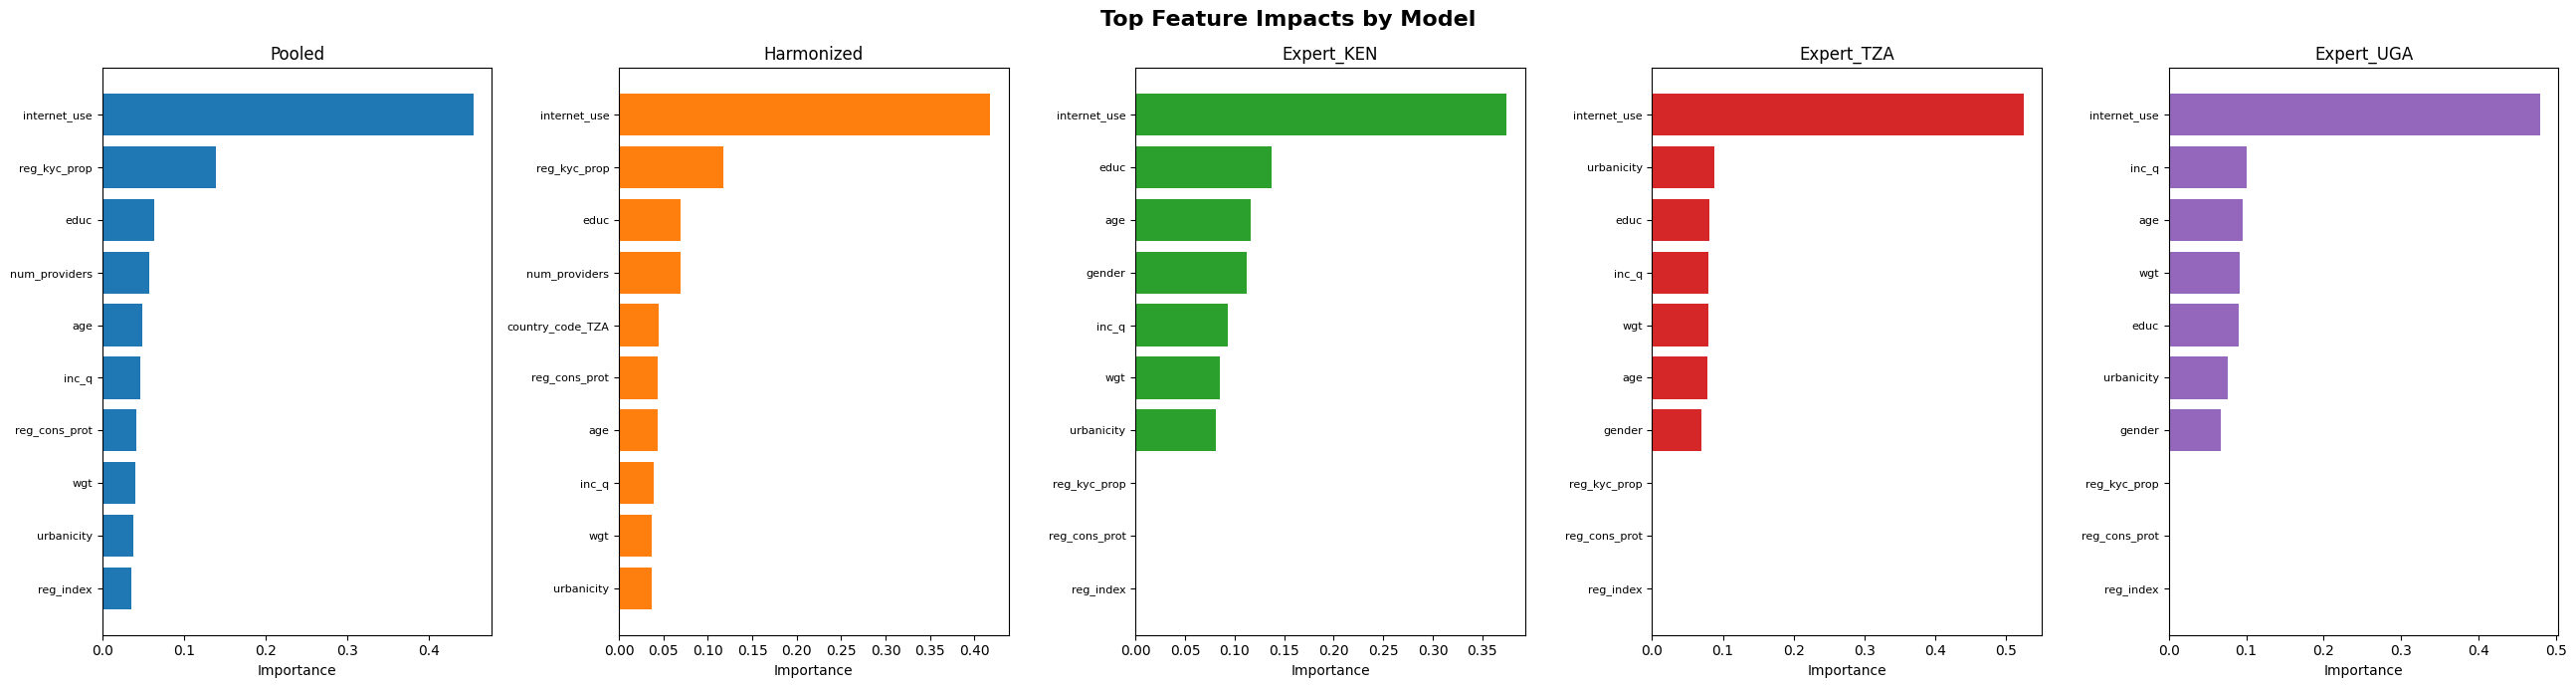

Saved feature impact chart:
/content/drive/MyDrive/Financial_Inclusion_Models/feature_impact_comparison.png


In [58]:
# FEATURE IMPACT COMPARISON FOR EACH MODEL

def get_feature_importance_df(model, model_name, feature_names, top_n=10):

    fi = pd.DataFrame({
        "Model": model_name,
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    fi = fi.sort_values(
        by="Importance",
        ascending=False
    ).head(top_n)

    return fi


# Collect feature importance


all_fi_tables = []

all_fi_tables.append(
    get_feature_importance_df(
        pooled_model,
        "Pooled",
        X_train.columns,
        top_n=10
    )
)

all_fi_tables.append(
    get_feature_importance_df(
        harmonized_model,
        "Harmonized",
        X_train.columns,
        top_n=10
    )
)

for c in countries:
    all_fi_tables.append(
        get_feature_importance_df(
            expert_models[c],
            f"Expert_{c}",
            X_train.columns,
            top_n=10
        )
    )

feature_impact_df = pd.concat(
    all_fi_tables,
    ignore_index=True
)

display(feature_impact_df)


# Save feature impact table

joblib.dump(
    feature_impact_df,
    os.path.join(
        MODEL_PATH,
        "feature_impact_table.joblib"
    )
)

feature_impact_df.to_csv(
    os.path.join(
        MODEL_PATH,
        "feature_impact_table.csv"
    ),
    index=False
)


# Plot all models in one row

model_order = [
    "Pooled",
    "Harmonized",
    "Expert_KEN",
    "Expert_TZA",
    "Expert_UGA"
]

colors = {
    "Pooled": "#1f77b4",
    "Harmonized": "#ff7f0e",
    "Expert_KEN": "#2ca02c",
    "Expert_TZA": "#d62728",
    "Expert_UGA": "#9467bd"
}

fig, axes = plt.subplots(
    1,
    len(model_order),
    figsize=(26, 7),
    sharex=False
)

for ax, model_name in zip(axes, model_order):

    temp = feature_impact_df[
        feature_impact_df["Model"] == model_name
    ].sort_values(
        by="Importance",
        ascending=True
    )

    ax.barh(
        temp["Feature"],
        temp["Importance"],
        color=colors[model_name]
    )

    ax.set_title(model_name)
    ax.set_xlabel("Importance")

    ax.tick_params(axis="y", labelsize=8)

plt.suptitle(
    "Top Feature Impacts by Model",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

figure_path = os.path.join(
    MODEL_PATH,
    "feature_impact_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved feature impact chart:")
print(figure_path)

In [59]:
import joblib

feature_columns = list(pooled_model.feature_names_in_)

joblib.dump(
    feature_columns,
    "/content/drive/MyDrive/Financial_Inclusion_Models/feature_columns.joblib"
)

print("feature_columns.joblib updated.")
print("gender" in feature_columns)
print("female" in feature_columns)

feature_columns.joblib updated.
True
False


**Building Model Probability**

In [60]:
# GENERATE PREDICTION PROBABILITIES FROM ALL MODELS

def get_model_probabilities(X_data):

    model_probabilities = pd.DataFrame(
        index=X_data.index
    )

    # Generalized models
    model_probabilities["Pooled"] = (
        pooled_model.predict_proba(X_data)[:, 1]
    )

    model_probabilities["Harmonized"] = (
        harmonized_model.predict_proba(X_data)[:, 1]
    )

    # Country-specific expert models
    for country in countries:

        model_probabilities[f"Expert_{country}"] = (
            expert_models[country]
            .predict_proba(X_data)[:, 1]
        )

    return model_probabilities


# Generate probabilities for routing model training
train_model_probabilities = get_model_probabilities(
    X_train
)

# Generate probabilities for model evaluation
test_model_probabilities = get_model_probabilities(
    X_test
)

display(
    train_model_probabilities.head()
)

,Pooled,Harmonized,Expert_KEN,Expert_TZA,Expert_UGA
335,0.9842,0.9855,0.9967,0.9579,0.6964
2739,0.2439,0.3178,0.9604,0.2440,0.0929
1353,0.2781,0.2114,0.9914,0.2345,0.0625
1630,0.9919,0.9922,0.9901,0.9916,0.9920
244,0.2870,0.3222,0.2429,0.1844,0.2679


In [61]:
# CONSTRUCTION OF ROUTING LABELS

def build_routing_labels(model_probabilities, y_true):

    routing_labels = []

    for idx in model_probabilities.index:

        # Actual observed outcome
        actual_value = y_true.loc[idx]

        # Prediction probabilities from all models
        prediction_row = model_probabilities.loc[idx]

        # Calculate prediction error for each model
        prediction_errors = abs(
            prediction_row - actual_value
        )

        # Select model with lowest error
        best_model = prediction_errors.idxmin()

        routing_labels.append(best_model)

    return pd.Series(
        routing_labels,
        index=model_probabilities.index
    )


# Generate routing labels for training data
routing_labels_train = build_routing_labels(
    train_model_probabilities,
    y_train
)

# Generate routing labels for test data
routing_labels_test = build_routing_labels(
    test_model_probabilities,
    y_test
)

print("Routing label distribution:")
print(
    routing_labels_train.value_counts()
)

Routing label distribution:
Expert_KEN    1328
Expert_UGA     429
Expert_TZA     420
Pooled         119
Harmonized     104
Name: count, dtype: int64


In [62]:
# DEVELOPMENT OF THE ROUTING MODEL

from sklearn.ensemble import RandomForestClassifier

# Combine original input features with model probability outputs
router_X_train = pd.concat(
    [X_train, train_model_probabilities],
    axis=1
)

router_X_test = pd.concat(
    [X_test, test_model_probabilities],
    axis=1
)

# Define routing model
routing_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

# Train routing model using routing labels
routing_model.fit(
    router_X_train,
    routing_labels_train
)

print("Routing model trained successfully.")
print("Router classes:", routing_model.classes_)

Routing model trained successfully.
Router classes: ['Expert_KEN' 'Expert_TZA' 'Expert_UGA' 'Harmonized' 'Pooled']


In [63]:
#  EVALUATE ROUTER

router_pred = routing_model.predict(router_X_test)

router_accuracy = accuracy_score(
    routing_labels_test,
    router_pred
)

print("Router Accuracy:", router_accuracy)

print("\nRouting Classification Report:")
print(classification_report(routing_labels_test, router_pred))

Router Accuracy: 0.6166666666666667

Routing Classification Report:
              precision    recall  f1-score   support

  Expert_KEN       0.69      0.81      0.74       323
  Expert_TZA       0.45      0.43      0.44        98
  Expert_UGA       0.51      0.58      0.54        90
  Harmonized       0.50      0.03      0.05        37
      Pooled       0.59      0.25      0.35        52

    accuracy                           0.62       600
   macro avg       0.55      0.42      0.43       600
weighted avg       0.60      0.62      0.59       600



In [64]:
# INTEGRATION OF THE MIXTURE OF EXPERTS FRAMEWORK
# Models selected by routing mechanism
import pandas as pd

selected_models = pd.Series(
    router_pred,
    index=X_test.index
)

# Generate final MoE probabilities
moe_probabilities = []

for idx in X_test.index:

    selected_model = selected_models.loc[idx]

    selected_probability = test_model_probabilities.loc[
        idx,
        selected_model
    ]

    moe_probabilities.append(
        selected_probability
    )

moe_probabilities = np.array(
    moe_probabilities
)

# Convert probabilities into binary predictions
moe_predictions = (
    moe_probabilities >= 0.5
).astype(int)

# Evaluate final Mixture of Experts performance
moe_metrics = {

    "Model": "MoE_Router",

    "Accuracy": accuracy_score(
        y_test,
        moe_predictions
    ),

    "Precision": precision_score(
        y_test,
        moe_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        moe_predictions,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        moe_predictions,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        moe_probabilities
    )
}

print(moe_metrics)

{'Model': 'MoE_Router', 'Accuracy': 0.7516666666666667, 'Precision': 0.8139059304703476, 'Recall': 0.8728070175438597, 'F1': 0.8423280423280424, 'ROC_AUC': np.float64(0.7292275828460039)}


In [65]:
# FINAL MODEL COMPARISON

final_comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame([moe_metrics])
    ],
    ignore_index=True
)

final_comparison_df = final_comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(final_comparison_df)

joblib.dump(
    final_comparison_df,
    os.path.join(MODEL_PATH, "final_model_comparison.joblib")
)

final_comparison_df.to_csv(
    os.path.join(MODEL_PATH, "final_model_comparison.csv"),
    index=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Expert_KEN,0.8844,0.9058,0.9719,0.9377,0.7528
1,Pooled,0.7600,0.8171,0.8816,0.8481,0.8106
2,Harmonized,0.7583,0.8116,0.8882,0.8482,0.8132
3,MoE_Router,0.7517,0.8139,0.8728,0.8423,0.7292
4,Expert_UGA,0.7269,0.8079,0.8512,0.8290,0.7140
5,Expert_TZA,0.6324,0.6750,0.7364,0.7043,0.7207


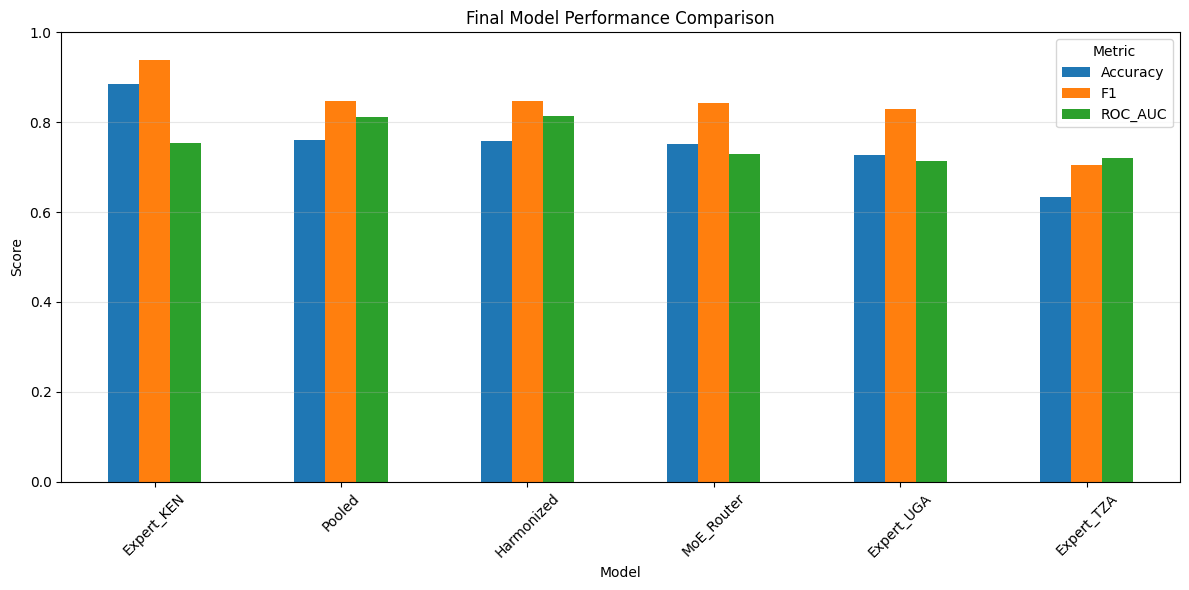

Saved chart: /content/drive/MyDrive/Financial_Inclusion_Models/final_model_comparison_chart.png


In [66]:
# FINAL COMPARISON CHART

metrics_df = final_comparison_df[
    ["Model", "Accuracy", "F1", "ROC_AUC"]
].set_index("Model")

ax = metrics_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.xticks(rotation=45)
plt.tight_layout()

chart_path = os.path.join(
    MODEL_PATH,
    "final_model_comparison_chart.png"
)

plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart:", chart_path)

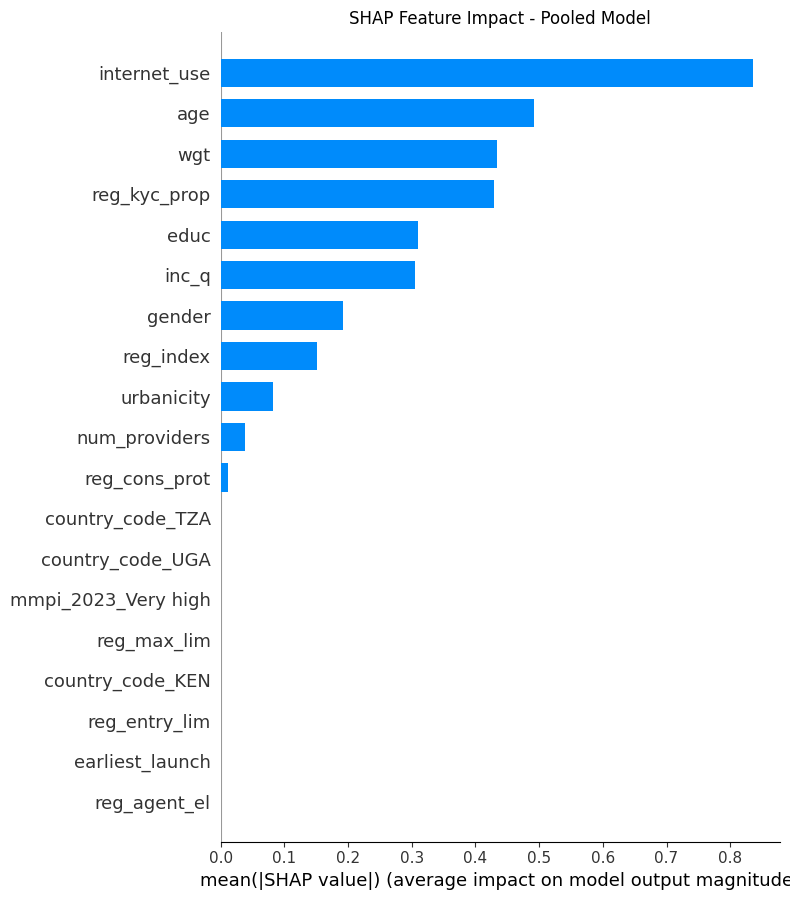

Saved SHAP chart: /content/drive/MyDrive/Financial_Inclusion_Models/shap_feature_impact_pooled.png


In [67]:
#  SHAP EXPLAINABILITY

!pip install shap -q

import shap

shap_sample = X_test.sample(
    min(200, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(pooled_model)

shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(
    shap_values,
    shap_sample,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Impact - Pooled Model")
plt.tight_layout()

shap_path = os.path.join(
    MODEL_PATH,
    "shap_feature_impact_pooled.png"
)

plt.savefig(shap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved SHAP chart:", shap_path)

In [68]:
# SAVE ROUTER AND SUPPORT FILES

joblib.dump(
    routing_model,
    os.path.join(MODEL_PATH, "routing_model.joblib")
)

joblib.dump(
    train_model_probs.columns.tolist(),
    os.path.join(MODEL_PATH, "model_probability_columns.joblib")
)

print("Saved routing_model.joblib")
print("Saved model_probability_columns.joblib")

print("\nFiles in model folder:")
for f in sorted(os.listdir(MODEL_PATH)):
    print(f)

NameError: name 'train_model_probs' is not defined

In [ ]:
import os
for f in sorted(os.listdir("/content/drive/MyDrive/Financial_Inclusion_Models")):
    print(f)

In [ ]:
#Verify all files
import os

MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"

for f in sorted(os.listdir(MODEL_PATH)):
    print(f)

In [ ]:
#View Mode Details

import joblib

MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"

files = [
    "pooled_model.joblib",
    "harmonized_model.joblib",
    "expert_model_KEN.joblib",
    "expert_model_TZA.joblib",
    "expert_model_UGA.joblib",
    "routing_model.joblib"
]

for file in files:

    model = joblib.load(f"{MODEL_PATH}/{file}")

    print("\n" + "="*60)
    print(file)
    print(type(model))

    if hasattr(model, "feature_importances_"):
        print("Features:", len(model.feature_importances_))

    if hasattr(model, "classes_"):
        print("Classes:", model.classes_)

In [ ]:
#Viewing Final Model Comparison
import pandas as pd

comparison = pd.read_csv(
    "/content/drive/MyDrive/Financial_Inclusion_Models/final_model_comparison.csv"
)

display(comparison)

In [ ]:
import joblib

joblib.dump(
    X.columns.tolist(),
    "/content/drive/MyDrive/Financial_Inclusion_Models/feature_columns.joblib"
)

print("feature_columns.joblib saved.")

In [ ]:
import joblib

features = joblib.load(
    "/content/drive/MyDrive/Financial_Inclusion_Models/feature_columns.joblib"
)

print("Number of features:", len(features))
print(features[:21])

In [ ]:

import os

MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"

required_files = [

    "feature_columns.joblib",

    "pooled_model.joblib",
    "harmonized_model.joblib",

    "expert_model_KEN.joblib",
    "expert_model_TZA.joblib",
    "expert_model_UGA.joblib",

    "routing_model.joblib",

    "final_model_comparison.csv",
    "feature_impact_table.csv",

    "final_model_comparison_chart.png",
    "feature_impact_comparison.png",
    "shap_feature_impact_pooled.png",

    "cleanfinancialinclusion.ipynb"
]

print("CHECKING FILES\n")

for file in required_files:

    exists = os.path.exists(
        os.path.join(MODEL_PATH, file)
    )

    print(f"{file:<40} {'✅' if exists else '❌'}")


In [ ]:
joblib.dump(list(X_train.columns), 'feature_names.pkl')

In [ ]:
print(df.columns.tolist())

In [ ]:
print(df.columns.tolist())
print(X.shape)
print(y.value_counts())

In [ ]:
# COUNTRY MODEL COMPARISON

country_rows = []
country_test_clean = country_test.astype(str).str.upper()

model_prob_dict = {
    "Pooled": pooled_prob,
    "Harmonized": harm_prob,
    "MoE_Router": moe_probs
}

model_pred_dict = {
    "Pooled": pooled_pred,
    "Harmonized": harm_pred,
    "MoE_Router": moe_pred
}

for c in countries:
    mask = country_test_clean.values == c

    for model_name in model_pred_dict:
        country_rows.append({
            "Country": c,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test[mask], model_pred_dict[model_name][mask]),
            "F1": f1_score(y_test[mask], model_pred_dict[model_name][mask], zero_division=0),
            "ROC_AUC": roc_auc_score(y_test[mask], model_prob_dict[model_name][mask])
        })

country_model_df = pd.DataFrame(country_rows)

display(country_model_df)

country_model_df.to_csv(
    os.path.join(MODEL_PATH, "country_model_comparison.csv"),
    index=False
)

plt.figure(figsize=(10, 6))

plot_df = country_model_df.pivot(
    index="Country",
    columns="Model",
    values="Accuracy"
)

plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("Model Accuracy by Country")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

path = os.path.join(MODEL_PATH, "country_model_comparison.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path)

In [ ]:
# GENDER FAIRNESS COMPARISON

gender_rows = []

gender_col = None

if "gender" in X_test.columns:
    gender_col = "gender"
elif "female" in X_test.columns:
    gender_col = "female"

if gender_col is None:
    print("No gender or female column found.")
    print(X_test.columns.tolist())
else:
    print(X_test[gender_col].value_counts(dropna=False))

    unique_vals = sorted(X_test[gender_col].dropna().unique())

    if gender_col == "female":
        gender_map = {
            0: "Male",
            1: "Female"
        }
    elif set(unique_vals).issubset({0, 1}):
        gender_map = {
            0: "Male",
            1: "Female"
        }
    elif set(unique_vals).issubset({1, 2}):
        gender_map = {
            1: "Female",
            2: "Male"
        }
    else:
        gender_map = {}

    gender_values = X_test[gender_col].map(gender_map)

    print("\nMapped gender values:")
    print(gender_values.value_counts(dropna=False))

    for g in gender_values.dropna().unique():
        mask = gender_values == g

        gender_rows.append({
            "Gender": g,
            "N": mask.sum(),
            "Accuracy": accuracy_score(y_test[mask], moe_pred[mask]),
            "F1": f1_score(y_test[mask], moe_pred[mask], zero_division=0),
            "ROC_AUC": roc_auc_score(y_test[mask], moe_probs[mask])
        })

gender_fairness_df = pd.DataFrame(gender_rows)

display(gender_fairness_df)

In [ ]:
#  URBAN / RURAL PERFORMANCE

residence_rows = []

print("Urbanicity values in X_test:")
print(X_test["urbanicity"].value_counts(dropna=False))

if "urbanicity" in X_test.columns:

    unique_vals = sorted(X_test["urbanicity"].dropna().unique())

    if set(unique_vals).issubset({0, 1}):
        residence_map = {
            0: "Rural",
            1: "Urban"
        }
    elif set(unique_vals).issubset({1, 2}):
        residence_map = {
            1: "Urban",
            2: "Rural"
        }
    else:
        residence_map = {}

    residence_values = X_test["urbanicity"].map(residence_map)

    print("\nMapped residence values:")
    print(residence_values.value_counts(dropna=False))

    for r in residence_values.dropna().unique():

        mask = residence_values == r

        residence_rows.append({
            "Residence": r,
            "N": mask.sum(),
            "Accuracy": accuracy_score(y_test[mask], moe_pred[mask]),
            "F1": f1_score(y_test[mask], moe_pred[mask], zero_division=0),
            "ROC_AUC": roc_auc_score(y_test[mask], moe_probs[mask])
        })

residence_df = pd.DataFrame(residence_rows)

display(residence_df)

residence_df.to_csv(
    os.path.join(MODEL_PATH, "urban_rural_results.csv"),
    index=False
)

residence_df.set_index("Residence")[["Accuracy", "F1", "ROC_AUC"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("MoE Performance by Residence")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

path = os.path.join(MODEL_PATH, "urban_rural_chart.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path)

In [ ]:
# ROUTER SELECTION DISTRIBUTION

router_selection_df = pd.DataFrame({
    "Selected_Model": selected_models.values
})

router_counts = router_selection_df["Selected_Model"].value_counts().reset_index()
router_counts.columns = ["Selected_Model", "Count"]

display(router_counts)

router_counts.to_csv(
    os.path.join(MODEL_PATH, "router_selection_distribution.csv"),
    index=False
)

plt.figure(figsize=(9, 5))

plt.bar(
    router_counts["Selected_Model"],
    router_counts["Count"]
)

plt.title("Router Model Selection Distribution")
plt.ylabel("Count")
plt.xlabel("Selected Model")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

path = os.path.join(MODEL_PATH, "router_selection_distribution.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path)

In [ ]:
# CHECK NEW DISSERTATION OUTPUTS

new_outputs = [
    "country_model_comparison.csv",
    "country_model_comparison.png",
    "gender_fairness_results.csv",
    "gender_fairness_chart.png",
    "urban_rural_results.csv",
    "urban_rural_chart.png",
    "router_selection_distribution.csv",
    "router_selection_distribution.png"
]

for file in new_outputs:
    exists = os.path.exists(os.path.join(MODEL_PATH, file))
    print(f"{file:<45} {'✅' if exists else '❌'}")

In [ ]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/cleaned_renamed_findex.csv"
)

print(df.head())

In [ ]:
print("Raw dataset:")
print(df.columns.tolist())

print("\nGender values:")
print(df["gender"].value_counts(dropna=False))

print("\nGender labels:")
print(df["gender_label"].value_counts(dropna=False))

In [ ]:
# CHECK NEW DISSERTATION OUTPUTS

new_outputs = [
    "country_model_comparison.csv",
    "country_model_comparison.png",
    "gender_fairness_results.csv",
    "gender_fairness_chart.png",
    "urban_rural_results.csv",
    "urban_rural_chart.png",
    "router_selection_distribution.csv",
    "router_selection_distribution.png"
]

for file in new_outputs:
    exists = os.path.exists(os.path.join(MODEL_PATH, file))
    print(f"{file:<45} {'✅' if exists else '❌'}")

In [ ]:
import pandas as pd

df_final = pd.read_csv(
    "https://raw.githubusercontent.com/sitahlango-maker/Financial_Inclusion/main/Colab%20Notebooks/FinancialInclution/final_combined_data.csv"
)

print(df_final.columns.tolist())

In [ ]:
print(df.columns.tolist())

print(
    "\nGender distribution:"
)

print(
    df["gender"].value_counts(dropna=False)
)

In [ ]:
import joblib

feature_cols = joblib.load(
    "/content/drive/MyDrive/Financial_Inclusion_Models/feature_columns.joblib"
)

print("gender" in feature_cols)
print("female" in feature_cols)

In [ ]:
X, y, country = preprocess_data(df)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

country_train = country.loc[X_train.index]
country_test = country.loc[X_test.index]

print("gender" in X_test.columns)
print("female" in X_test.columns)
print(X_test["gender"].value_counts())

In [ ]:
import os
import joblib

MODEL_PATH = "/content/drive/MyDrive/Financial_Inclusion_Models"

files = [
    "feature_columns.joblib",
    "pooled_model.joblib",
    "harmonized_model.joblib",
    "expert_model_KEN.joblib",
    "expert_model_TZA.joblib",
    "expert_model_UGA.joblib",
    "routing_model.joblib"
]

for f in files:
    print(f, "✅" if os.path.exists(os.path.join(MODEL_PATH, f)) else "❌")

feature_cols = joblib.load(
    os.path.join(MODEL_PATH, "feature_columns.joblib")
)

print("\nContains gender:", "gender" in feature_cols)
print("Contains female:", "female" in feature_cols)

In [ ]:
import joblib

features = joblib.load("feature_columns.joblib")
print("gender" in features)
print("female" in features)

In [ ]:
# CHECK NEW DISSERTATION OUTPUTS

new_outputs = [
    "country_model_comparison.csv",
    "country_model_comparison.png",
    "gender_fairness_results.csv",
    "gender_fairness_chart.png",
    "urban_rural_results.csv",
    "urban_rural_chart.png",
    "router_selection_distribution.csv",
    "router_selection_distribution.png"
]

for file in new_outputs:
    exists = os.path.exists(os.path.join(MODEL_PATH, file))
    print(f"{file:<45} {'✅' if exists else '❌'}")

In [ ]:
print(df["gender"].value_counts())

In [ ]:
import joblib

pooled = joblib.load(
    "/content/drive/MyDrive/Financial_Inclusion_Models/pooled_model.joblib"
)

print(pooled.feature_names_in_)

In [ ]:
print("Urbanicity distribution:")
print(df["urbanicity"].value_counts(dropna=False).sort_index())

residence_values = df["urbanicity"].map({
    1: "Urban",
    2: "Rural"
})

print("\nResidence distribution:")
print(residence_values.value_counts(dropna=False))

In [ ]:
print("Urbanicity in X_test:")
print(X_test["urbanicity"].value_counts(dropna=False).sort_index())

residence_values_test = X_test["urbanicity"].map({
    1: "Urban",
    2: "Rural"
})

print("\nMapped residence in X_test:")
print(residence_values_test.value_counts(dropna=False))

In [ ]:
print(df["internet_use"].value_counts(dropna=False).sort_index())

In [ ]:
# GITHUB REPOSITORY

!rm -rf /content/Financial_Inclusion
!git clone https://github.com/sitahlango-maker/Financial_Inclusion.git

%cd /content/Financial_Inclusion

In [ ]:
# ==========================================================
# 6. COMMIT CHANGES
# ==========================================================

!git add .

!git commit -m "Update gender-standardized models and evaluation outputs"

In [ ]:
# ==========================================================
# 7. PUSH TO GITHUB
# Replace YOUR_GITHUB_TOKEN with your token
# ==========================================================

TOKEN = "YOUR_GITHUB_TOKEN"

!git remote set-url origin https://{TOKEN}@github.com/sitahlango-maker/Financial_Inclusion.git

!git push origin main